In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_testam_chestii(image, size=512):
    img_resized = cv2.resize(image, (size, size))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)

    contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return gray

    contur_ochi = max(contours, key=cv2.contourArea)
    masca_ochi = np.zeros((size, size), dtype=np.uint8)
    cv2.drawContours(masca_ochi, [contur_ochi], -1, 255, thickness=cv2.FILLED)

    kernel_eroziune = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    masca_ochi = cv2.erode(masca_ochi, kernel_eroziune, iterations=1)

    sigma_x = size / 30.0
    blur = cv2.GaussianBlur(gray, (0, 0), sigma_x)
    ben_graham_gray = cv2.addWeighted(gray, 4, blur, -4, 128)

    masca_exterior = cv2.bitwise_not(masca_ochi)
    dist = cv2.distanceTransform(masca_exterior, cv2.DIST_L2, 5)
    halo_width = 35.0

    rezultat_final = np.full((size, size), 128.0, dtype=np.float32)
    halo_mask = (dist > 0) & (dist <= halo_width)
    fraction = dist[halo_mask] / halo_width
    rezultat_final[halo_mask] = 128.0 * fraction

    interior_mask = masca_ochi == 255
    rezultat_final[interior_mask] = ben_graham_gray[interior_mask]

    return rezultat_final.astype(np.uint8)


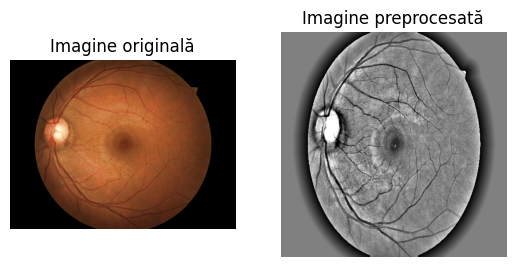

In [5]:
src_path = r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset\train\0\13_left.jpeg"
img = cv2.imread(src_path)
rezultat = preprocess_testam_chestii(img)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagine originală")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rezultat, cmap="gray")
plt.title("Imagine preprocesată")
plt.axis("off")
plt.show()